In [2]:
# Package imports
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.autograd import Variable
from torchvision.utils import save_image


In [4]:

# MNIST Dataset
train_dataset = datasets.MNIST(root='../torch_tutorial/data', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='../torch_tutorial/data/', train=False, transform=transforms.ToTensor(), download=True)


In [5]:
bs=128
# Data Loader
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=bs, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=bs, shuffle=False)

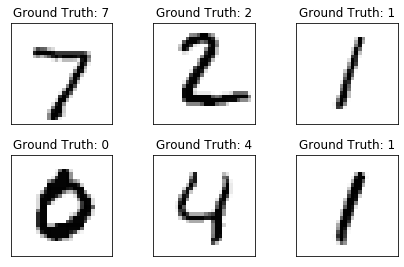

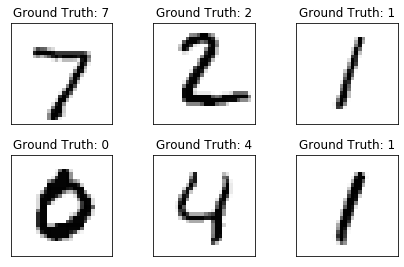

In [6]:
classes = ('0', '1', '2', '3',
           '4', '5', '6', '7', '8', '9')
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples) 
# example_data.shape is torch.Size([128, 1, 28, 28])
# example_targets.shape is torch.Size([128])

fig = plt.figure()
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.tight_layout()
  plt.imshow(1-example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Ground Truth: {}".format(example_targets[i]))
  plt.xticks([])
  plt.yticks([])
fig

In [7]:
example_targets.shape

torch.Size([128])

In [8]:

class VAE(nn.Module):
    def __init__(self, x_dim, h_dim1, h_dim2, z_dim):
        super(VAE, self).__init__()
        
        # encoder
        self.encoder = nn.Sequential(
            nn.Linear(x_dim, h_dim1),
            nn.LeakyReLU(0.2),
            nn.Linear(h_dim1, h_dim2),
            nn.LeakyReLU(0.2)
            )
        
        # latent mean and variance 
        self.mean_layer = nn.Linear(h_dim2, z_dim)
        self.logvar_layer = nn.Linear(h_dim2, z_dim)
  
        # decoder
        self.decoder = nn.Sequential(
            nn.Linear(z_dim, h_dim2),
            nn.LeakyReLU(0.2),
            nn.Linear(h_dim2, h_dim1),
            nn.LeakyReLU(0.2),
            nn.Linear(h_dim1, x_dim),
            nn.Sigmoid()
            )
 
    def encode(self, x):
        x = self.encoder(x)
        mu, log_var = self.mean_layer(x), self.logvar_layer(x)
        return mu, log_var
    
    # sample z from q(z/x) by reparameterization trick
    def reparameterization(self, mu, log_var):
        std = torch.exp(0.5*log_var)
        eps = torch.randn_like(std)
        z = eps.mul(std).add_(mu)
        return z 
  
    def decode(self, x):
        return self.decoder(x)
   
    def forward(self, x):
        mu, log_var = self.encode(x.view(-1, 784))
        z = self.reparameterization(mu, log_var)
        y = self.decode(z)
        return y, mu, log_var
 

In [26]:
h_dim1 = 512
h_dim2 = 256
z_dim = 2
vae = VAE(x_dim=784, h_dim1=h_dim1, h_dim2=h_dim2, z_dim=z_dim)
if torch.cuda.is_available():
    vae.cuda()  

In [28]:
optimizer = optim.Adam(vae.parameters(), lr=0.001)
# loss_function returns reconstruction error + KL divergence losses
def loss_function(recon_x, x, mu, log_var):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    KLD = 0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return BCE - KLD

In [29]:
def train(epoch):
    vae.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        #data = data.cuda()
        optimizer.zero_grad()
        
        recon_batch, mu, log_var = vae(data)
        loss = loss_function(recon_batch, data, mu, log_var)
        
        loss.backward()
        #train_loss += loss.item()
        optimizer.step()
        
        if batch_idx % 100 == 0:
            print('Epoch {} , Batch {}   \tLoss: {:.6f}'.format(
                epoch, (batch_idx), loss.item() / len(data)))
   

In [30]:
def test():
    vae.eval()
    test_loss= 0
    with torch.no_grad():
        for data, _ in test_loader:
            
            recon, mu, log_var = vae(data)
            
            # sum up batch loss
            test_loss += loss_function(recon, data, mu, log_var).item()
        
    test_loss /= len(test_loader.dataset)
    print('=> Test set average loss per batch: {:.4f}'.format(test_loss))

In [31]:
for epoch in range(1, 10):
    train(epoch)
    test()

Epoch 1 , Batch 0   	Loss: 544.850464
Epoch 1 , Batch 100   	Loss: 179.565323
Epoch 1 , Batch 200   	Loss: 175.723328
Epoch 1 , Batch 300   	Loss: 166.979980
Epoch 1 , Batch 400   	Loss: 166.461655
=> Test set average loss per batch: 164.8808
Epoch 2 , Batch 0   	Loss: 164.763397
Epoch 2 , Batch 100   	Loss: 163.795151
Epoch 2 , Batch 200   	Loss: 160.335480
Epoch 2 , Batch 300   	Loss: 159.901794
Epoch 2 , Batch 400   	Loss: 159.668457
=> Test set average loss per batch: 159.4086
Epoch 3 , Batch 0   	Loss: 153.805344
Epoch 3 , Batch 100   	Loss: 157.650543
Epoch 3 , Batch 200   	Loss: 161.377319
Epoch 3 , Batch 300   	Loss: 150.701462
Epoch 3 , Batch 400   	Loss: 146.304733
=> Test set average loss per batch: 156.4882
Epoch 4 , Batch 0   	Loss: 155.285492
Epoch 4 , Batch 100   	Loss: 147.864578
Epoch 4 , Batch 200   	Loss: 160.023560
Epoch 4 , Batch 300   	Loss: 153.829132
Epoch 4 , Batch 400   	Loss: 149.507004
=> Test set average loss per batch: 153.5270
Epoch 5 , Batch 0   	Loss: 1

In [32]:
with torch.no_grad():
    z = torch.randn(64, z_dim) 
    sample = vae.decode(z) 
    # generate 64 samples
    save_image(1-sample.view(64, 1, 28, 28), './samples/sample_weidong_z2' + '.png')

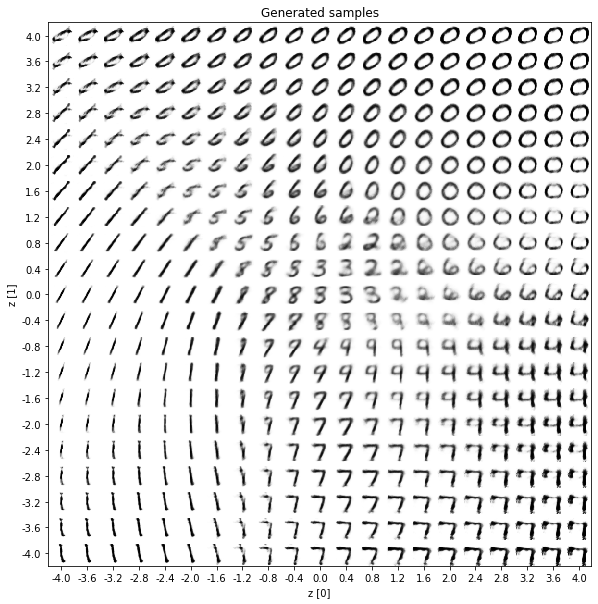

In [34]:
def plot_reconstructed(model, scale=1.0, n=21, digit_size=28, figsize=10):
    # display a n*n handwritten digits in the 2D latent space
    figure = np.zeros((digit_size * n, digit_size * n))

    # construct a grid in the 2D Z space
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1] #reverse the order

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float)
            x_decoded = model.decode(z_sample)
            digit = x_decoded[0].detach().cpu().reshape(digit_size, digit_size)
            figure[i * digit_size : (i + 1) * digit_size, j * digit_size : (j + 1) * digit_size,] = 1-digit

    plt.figure(figsize=(figsize, figsize))
    plt.title('Generated samples')
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("z [0]")
    plt.ylabel("z [1]")
    plt.imshow(figure, cmap="Greys_r")
    plt.show()


plot_reconstructed(vae, scale=4.)

In [16]:
def plot_reconstructed2(vae, r0=(-5, 5), r1=(-5, 5), n=12):
    w = 28
    img = np.zeros((n*w, n*w))
    for i, y in enumerate(np.linspace(*r1, n)):
        for j, x in enumerate(np.linspace(*r0, n)):
            z = torch.Tensor([[x, y]])
            x_hat = vae.decode(z)
            x_hat = x_hat.reshape(28, 28).to('cpu').detach().numpy()
            img[(n-1-i)*w:(n-1-i+1)*w, j*w:(j+1)*w] = x_hat
    plt.imshow(img, extent=[*r0, *r1])

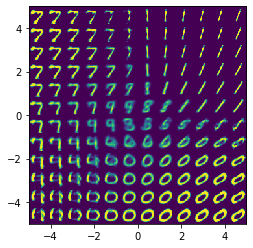

In [17]:
plot_reconstructed2(vae)

In [35]:
def plot_latent(vae, data, num_batches=100):
    for i, (x, y) in enumerate(data):
        mu, log_var = vae.encode(x.view(-1, 784))
        z = vae.reparameterization(mu, log_var)
        z = z.detach().numpy()
        plt.scatter(z[:, 0], z[:, 1], c=y, cmap='tab10')
        if i > num_batches:
            break
    plt.colorbar()
    plt.xlabel("z [0]")
    plt.ylabel("z [1]")
    plt.show()

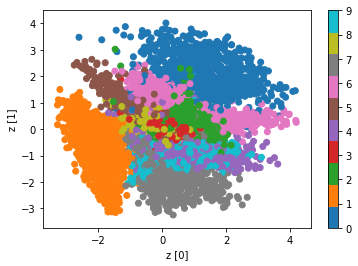

In [36]:
plot_latent(vae, test_loader)

In [98]:
len(train_loader)

469